# Figure 4.4

Validation passed on 5 sampled k_o values.


k_o sweep (bisect):   0%|          | 0/200 [00:00<?, ?it/s]

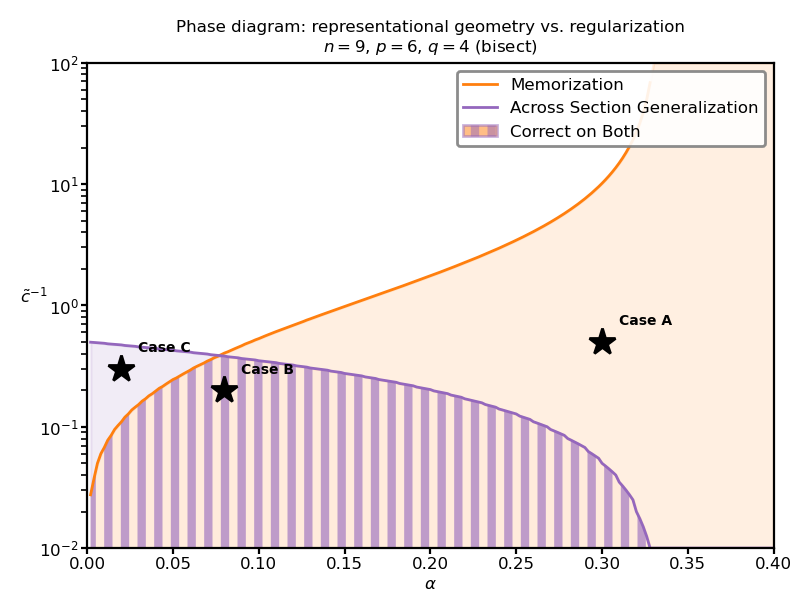

In [2]:
#figure 4b

# ---- Tier 1 + Tier 2: binary-search sweep (assumes monotonicity in c_reg) ----
# Builds one Ranking_exp per probe (not per critical-pair); bisects the
# c_var index at which each margin first flips negative.
#
# Before running the full sweep, we validate against the linear scan on a
# small sample of k_o values so we'd catch any non-monotonic cases.

import sys, os, io, contextlib
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from Ranking_exp import Ranking_exp

# ------------------------- parameters (identical to linear sweep) ------------
n = 9
p = 6
q = 4
k_s = 1.0
k_d = 0.0
delta_s = k_s - k_d

k_o_vals   = np.arange(0.30, 0.4999, 0.001)
alpha_vals = 1.0 - 2.0 * (k_o_vals - k_d) / (k_s - k_d)
c_var_vals = np.arange(1e-2, 100, 0.0025)
c_vals     = 1.0 / (c_var_vals * delta_s)

test_critical_pair  = (q - 1, p + 1)
train_critical_pair = (q,     q + 1)


# ------------------------- helpers -------------------------------------------
def _make_sim(k_o, cr):
    with contextlib.redirect_stdout(io.StringIO()):
        return Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                           p=p, q=q, c_reg=cr)


def bisect_flip_both(k_o):
    """Return (c_var_test, c_var_train) at first flip, NaN if never flips.

    Uses one bisect per critical pair, reusing the sim at each probed index.
    """
    N = len(c_vals)

    def sim_at(i, _cache={}):
        if i not in _cache:
            _cache[i] = _make_sim(k_o, c_vals[i])
        return _cache[i]

    def first_flip(pair):
        # If the last c_reg (weakest regularization) hasn't flipped, skip.
        if sim_at(N - 1).f_j_k(*pair) >= 0:
            return np.nan
        lo, hi = 0, N - 1
        while lo < hi:
            mid = (lo + hi) // 2
            if sim_at(mid).f_j_k(*pair) < 0:
                hi = mid
            else:
                lo = mid + 1
        return c_var_vals[lo]

    return first_flip(test_critical_pair), first_flip(train_critical_pair)


def linear_flip_both(k_o):
    """Reference linear scan, for validation."""
    ft = None
    fr = None
    for i, cr in enumerate(c_vals):
        sim = _make_sim(k_o, cr)
        if ft is None and sim.f_j_k(*test_critical_pair) < 0:
            ft = c_var_vals[i]
        if fr is None and sim.f_j_k(*train_critical_pair) < 0:
            fr = c_var_vals[i]
        if ft is not None and fr is not None:
            break
    return (ft if ft is not None else np.nan,
            fr if fr is not None else np.nan)


# ------------------------- validation -----------------------------------------
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(k_o_vals), size=5, replace=False)
for si in sample_idx:
    k_o = k_o_vals[si]
    bt, br = bisect_flip_both(k_o)
    lt, lr = linear_flip_both(k_o)
    assert np.isclose(bt, lt, equal_nan=True) and np.isclose(br, lr, equal_nan=True), \
        f"Mismatch at k_o={k_o:.4f}: bisect=({bt},{br}) linear=({lt},{lr})"
print("Validation passed on 5 sampled k_o values.")


# ------------------------- full bisect sweep ---------------------------------
breaking_reg_test  = np.zeros_like(k_o_vals)
breaking_reg_train = np.zeros_like(k_o_vals)

for idx, k_o in enumerate(tqdm(k_o_vals, desc='k_o sweep (bisect)')):
    breaking_reg_test[idx], breaking_reg_train[idx] = bisect_flip_both(k_o)


# ------------------------- plot ----------------------------------------------
import matplotlib.patches as mpatches

train = breaking_reg_train
test  = breaking_reg_test

ylim_bot = 1e-2
ylim_top = 1e2
train_fill   = np.where(np.isnan(train), ylim_top, train)
test_fill    = np.where(np.isnan(test),  ylim_top, test)
overlap_fill = np.minimum(train_fill, test_fill)

ORANGE = '#ff7f0e'
PURPLE = '#9467bd'

case_conditions = [
    (1 - 2*0.35, 0.50, 'A'),
    (1 - 2*0.46, 0.20, 'B'),
    (1 - 2*0.49, 0.30, 'C'),
]

with plt.rc_context({'figure.dpi': 200, 'hatch.linewidth': 3.0}):
    fig, ax = plt.subplots(figsize=(4, 3.0))

    ax.plot(alpha_vals, train, lw=1.0, color=ORANGE,
            label='Memorization')
    ax.plot(alpha_vals, test,  lw=1.0, color=PURPLE,
            label='Across Section Generalization')

    ax.fill_between(alpha_vals, overlap_fill, train_fill,
                    where=(train_fill > test_fill), interpolate=True,
                    alpha=0.12, color=ORANGE)
    ax.fill_between(alpha_vals, overlap_fill, test_fill,
                    where=(test_fill > train_fill), interpolate=True,
                    alpha=0.12, color=PURPLE)

    ax.fill_between(alpha_vals, ylim_bot, overlap_fill,
                    facecolor=ORANGE, alpha=0.15)
    ax.fill_between(alpha_vals, ylim_bot, overlap_fill, facecolor='none',
                    edgecolor=PURPLE, hatch='||', linewidth=0, alpha=0.6)
    ax.add_patch(mpatches.Rectangle((0,0),0,0,
                 facecolor=ORANGE, edgecolor=PURPLE, hatch='||',
                 alpha=0.5, label='Correct on Both'))

    for alpha_c, c_inv_c, case_lbl in case_conditions:
        ax.plot(alpha_c, c_inv_c, marker='*', markersize=10, color='black',
                zorder=5)
        ax.annotate(f'Case {case_lbl}', (alpha_c, c_inv_c),
                    textcoords='offset points', xytext=(6, 6),
                    fontsize=5, fontweight='bold')

    ax.set_xlabel(r'$\alpha$', fontsize=6, labelpad=2)
    ax.set_ylabel(r'$\tilde{c}^{-1}$', fontsize=6, rotation=0, labelpad=2)
    ax.set_title(
        f'Phase diagram: representational geometry vs. regularization\n'
        f'$n={n}$, $p={p}$, $q={q}$ (bisect)',
        fontsize=6, pad=4
    )
    ax.legend(fontsize=6, framealpha=0.9, edgecolor='gray', loc='upper right')
    ax.tick_params(axis='both', length=2, pad=1, labelsize=6)

    ax.set_yscale('log')
    ax.set_xlim(0.0, 0.40)
    ax.set_ylim(ylim_bot, ylim_top)
    ax.grid(False)

    plt.tight_layout(pad=0.5)
    plt.show()
    fig.savefig("figure_4e_bisect.pdf", bbox_inches="tight")


n=9, p=6, q=4:   0%|          | 0/200 [00:00<?, ?it/s]

n=11, p=7, q=5:   0%|          | 0/200 [00:00<?, ?it/s]

n=11, p=8, q=4:   0%|          | 0/200 [00:00<?, ?it/s]

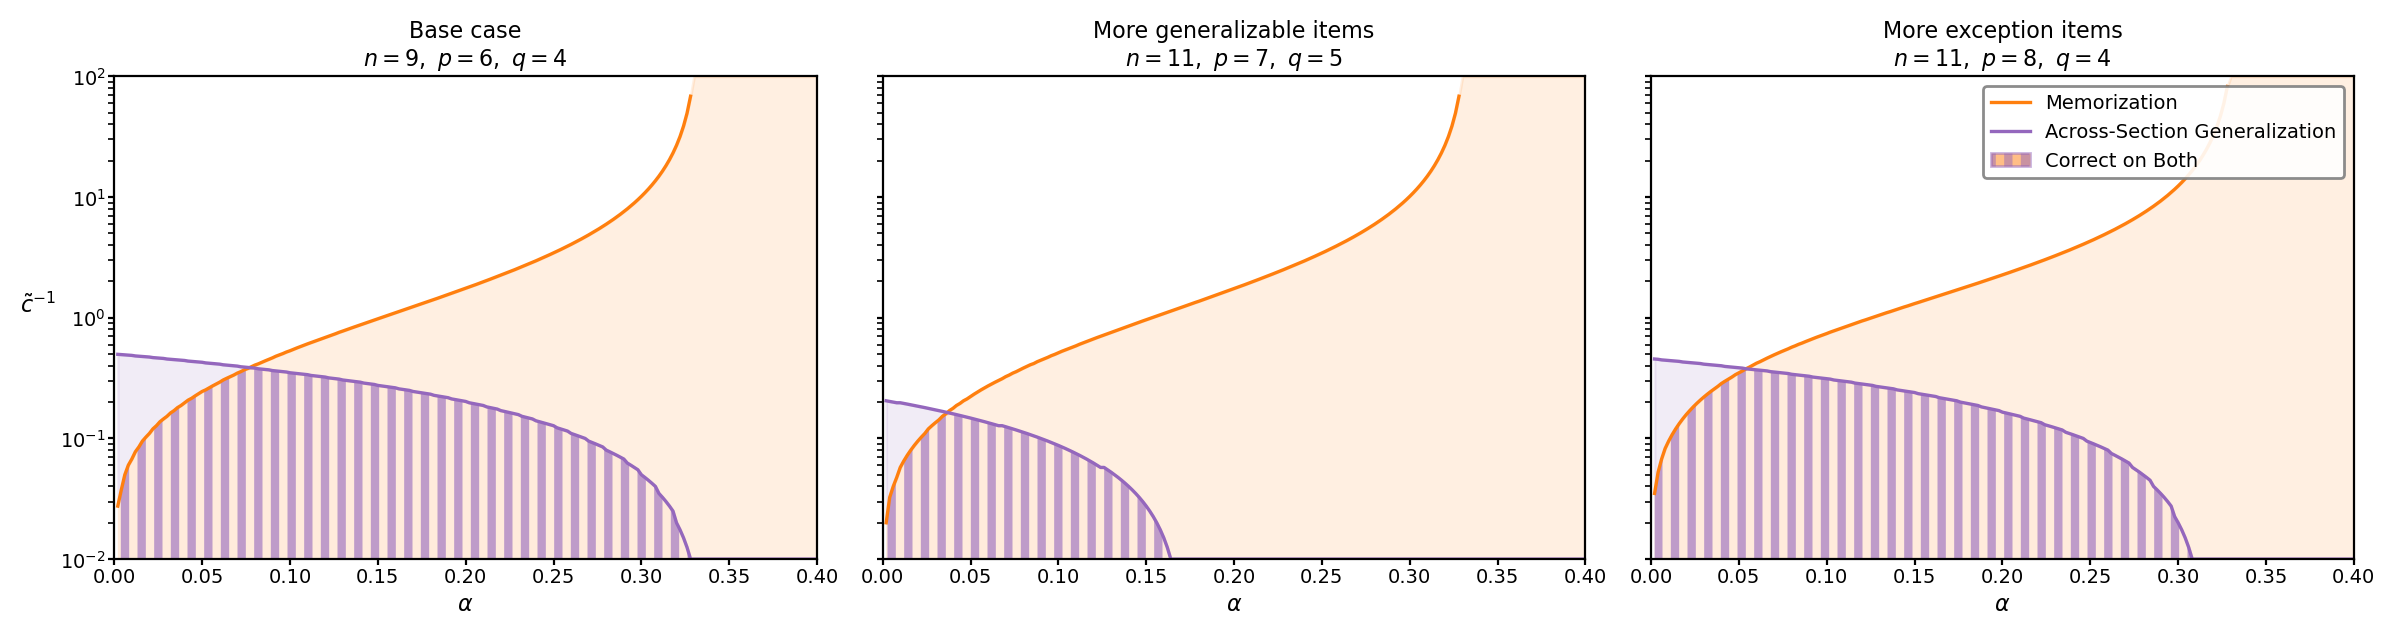

In [6]:
# 3-panel phase diagram: base case, more generalizable, more exceptions

import sys, os, io, contextlib
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm
from Ranking_exp import Ranking_exp

# ---------- three parameter sets ------------------------------------------
configs = [
    {'n': 9,  'p': 6, 'q': 4, 'title': 'Base case\n$n=9,\\ p=6,\\ q=4$'},
    {'n': 11, 'p': 7, 'q': 5, 'title': 'More generalizable items\n$n=11,\\ p=7,\\ q=5$'},
    {'n': 11, 'p': 8, 'q': 4, 'title': 'More exception items\n$n=11,\\ p=8,\\ q=4$'},
]

k_s = 1.0
k_d = 0.0
delta_s = k_s - k_d

k_o_vals   = np.arange(0.30, 0.4999, 0.001)
alpha_vals = 1.0 - 2.0 * (k_o_vals - k_d) / (k_s - k_d)
c_var_vals = np.arange(1e-2, 100, 0.0025)
c_vals     = 1.0 / (c_var_vals * delta_s)


def run_sweep(n, p, q):
    """Bisect sweep for one parameter configuration."""
    test_critical_pair  = (q - 1, p + 1)
    train_critical_pair = (q,     q + 1)

    def _make_sim(k_o, cr):
        with contextlib.redirect_stdout(io.StringIO()):
            return Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                               p=p, q=q, c_reg=cr)

    def bisect_flip_both(k_o):
        N = len(c_vals)
        cache = {}

        def sim_at(i):
            if i not in cache:
                cache[i] = _make_sim(k_o, c_vals[i])
            return cache[i]

        def first_flip(pair):
            if sim_at(N - 1).f_j_k(*pair) >= 0:
                return np.nan
            lo, hi = 0, N - 1
            while lo < hi:
                mid = (lo + hi) // 2
                if sim_at(mid).f_j_k(*pair) < 0:
                    hi = mid
                else:
                    lo = mid + 1
            return c_var_vals[lo]

        return first_flip(test_critical_pair), first_flip(train_critical_pair)

    breaking_test  = np.zeros_like(k_o_vals)
    breaking_train = np.zeros_like(k_o_vals)
    for idx, k_o in enumerate(tqdm(k_o_vals, desc=f'n={n}, p={p}, q={q}')):
        breaking_test[idx], breaking_train[idx] = bisect_flip_both(k_o)
    return breaking_test, breaking_train


# ---------- compute all sweeps --------------------------------------------
results = []
for cfg in configs:
    bt, br = run_sweep(cfg['n'], cfg['p'], cfg['q'])
    results.append((bt, br))

# ---------- plot ----------------------------------------------------------
ORANGE = '#ff7f0e'
PURPLE = '#9467bd'
ylim_bot = 1e-2
ylim_top = 1e2

with plt.rc_context({'figure.dpi': 200, 'hatch.linewidth': 3.0}):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)

    for ax, cfg, (test, train) in zip(axes, configs, results):
        train_fill   = np.where(np.isnan(train), ylim_top, train)
        test_fill    = np.where(np.isnan(test),  ylim_top, test)
        overlap_fill = np.minimum(train_fill, test_fill)

        ax.plot(alpha_vals, train, lw=1.2, color=ORANGE, label='Memorization')
        ax.plot(alpha_vals, test,  lw=1.2, color=PURPLE, label='Across-Section Generalization')

        ax.fill_between(alpha_vals, overlap_fill, train_fill,
                        where=(train_fill > test_fill), interpolate=True,
                        alpha=0.12, color=ORANGE)
        ax.fill_between(alpha_vals, overlap_fill, test_fill,
                        where=(test_fill > train_fill), interpolate=True,
                        alpha=0.12, color=PURPLE)

        ax.fill_between(alpha_vals, ylim_bot, overlap_fill,
                        facecolor=ORANGE, alpha=0.15)
        ax.fill_between(alpha_vals, ylim_bot, overlap_fill, facecolor='none',
                        edgecolor=PURPLE, hatch='||', linewidth=0, alpha=0.6)
        ax.add_patch(mpatches.Rectangle((0, 0), 0, 0,
                     facecolor=ORANGE, edgecolor=PURPLE, hatch='||',
                     alpha=0.5, label='Correct on Both'))

        ax.set_xlabel(r'$\alpha$', fontsize=8, labelpad=2)
        ax.set_title(cfg['title'], fontsize=8, pad=4)
        ax.tick_params(axis='both', length=2, pad=1, labelsize=7)
        ax.set_yscale('log')
        ax.set_xlim(0.0, 0.40)
        ax.set_ylim(ylim_bot, ylim_top)
        ax.grid(False)

    axes[0].set_ylabel(r'$\tilde{c}^{-1}$', fontsize=8, rotation=0, labelpad=8)
    axes[-1].legend(fontsize=7, framealpha=0.9, edgecolor='gray', loc='upper right')

    plt.tight_layout(pad=0.8)
    plt.show()
    fig.savefig("figure_4_4_three_panels.pdf", bbox_inches="tight")


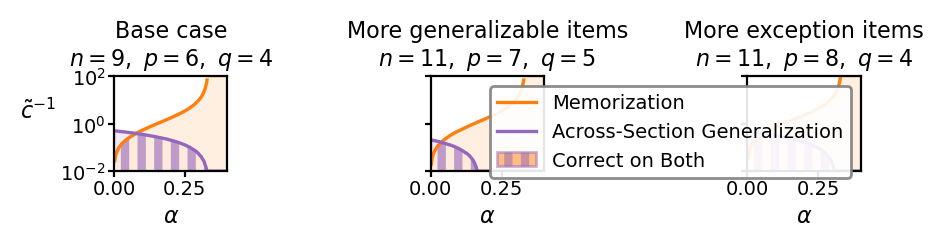

In [7]:
FIG_W_IN = 325.48499 / 72.27

with plt.rc_context({'figure.dpi': 200, 'hatch.linewidth': 3.0}):
    fig, axes = plt.subplots(1, 3, figsize=(FIG_W_IN, FIG_W_IN * 0.28), sharey=True)

    for ax, cfg, (test, train) in zip(axes, configs, results):
        train_fill   = np.where(np.isnan(train), ylim_top, train)
        test_fill    = np.where(np.isnan(test),  ylim_top, test)
        overlap_fill = np.minimum(train_fill, test_fill)

        ax.plot(alpha_vals, train, lw=1.2, color=ORANGE, label='Memorization')
        ax.plot(alpha_vals, test,  lw=1.2, color=PURPLE, label='Across-Section Generalization')

        ax.fill_between(alpha_vals, overlap_fill, train_fill,
                        where=(train_fill > test_fill), interpolate=True,
                        alpha=0.12, color=ORANGE)
        ax.fill_between(alpha_vals, overlap_fill, test_fill,
                        where=(test_fill > train_fill), interpolate=True,
                        alpha=0.12, color=PURPLE)

        ax.fill_between(alpha_vals, ylim_bot, overlap_fill,
                        facecolor=ORANGE, alpha=0.15)
        ax.fill_between(alpha_vals, ylim_bot, overlap_fill, facecolor='none',
                        edgecolor=PURPLE, hatch='||', linewidth=0, alpha=0.6)
        ax.add_patch(mpatches.Rectangle((0, 0), 0, 0,
                     facecolor=ORANGE, edgecolor=PURPLE, hatch='||',
                     alpha=0.5, label='Correct on Both'))

        ax.set_xlabel(r'$\alpha$', fontsize=8, labelpad=2)
        ax.set_title(cfg['title'], fontsize=8, pad=4)
        ax.tick_params(axis='both', length=2, pad=1, labelsize=7)
        ax.set_yscale('log')
        ax.set_xlim(0.0, 0.40)
        ax.set_ylim(ylim_bot, ylim_top)
        ax.grid(False)

    axes[0].set_ylabel(r'$\tilde{c}^{-1}$', fontsize=8, rotation=0, labelpad=8)
    axes[-1].legend(fontsize=7, framealpha=0.9, edgecolor='gray', loc='upper right')

    plt.tight_layout(pad=0.8)
    plt.show()
    fig.savefig("figure_4_4_three_panels.pdf", bbox_inches="tight")